In [1]:
import pandas as pd
import sys
import os
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from rapidfuzz import process, fuzz
import numpy as np

In [56]:
# df_matches = pd.read_parquet("/Users/samueleferrucci/Documents/Coding/Projects/Tennis ML/data/clean/merged_matches.csv")
df_matches = pd.read_parquet("s3://matchedge-pipeline/data/clean/merged_matches.parquet")

In [57]:
tot_cols = ["p1_first_serve", "p1_1st_serve_points_won", "p1_2nd_serve_points_won", "p1_1st_serve_return_points_won", 
            "p1_service_points_won", "p1_2nd_serve_return_points_won", "p1_return_points_won", "p1_total_points_won",
            "p2_first_serve", "p2_1st_serve_points_won", "p2_2nd_serve_points_won", "p2_1st_serve_return_points_won", 
            "p2_service_points_won", "p2_2nd_serve_return_points_won", "p2_return_points_won", "p2_total_points_won", 
            "p1_break_points_saved", "p1_break_points_converted", "p1_net_points_won", "p2_break_points_saved", 
            "p2_break_points_converted", "p2_net_points_won", "p2_break_point_opportunities", "p1_break_point_opportunities", 
            "p1_net_points_played", "p2_net_points_played" ,"p2_serve_rating", "p2_aces", "p2_double_faults", 
            "p2_service_games_played", "p2_return_rating", "p2_return_games_played", "p2_winners", "p2_unforced_errors", 
            "p2_max_speed", "p2_1st_serve_average_speed", "p2_2nd_serve_average_speed", "p1_break_point_opportunities", 
            "p1_net_points_played", 'p1_serve_rating', 'p1_aces', 'p1_double_faults', 'p1_first_serve', 
            'p1_1st_serve_points_won', 'p1_2nd_serve_points_won', 'p1_break_points_saved', 'p1_service_games_played', 
            'p1_return_rating', 'p1_1st_serve_return_points_won', 'p1_2nd_serve_return_points_won', 'p1_break_points_converted', 
            'p1_return_games_played', 'p1_net_points_won', 'p1_winners', 'p1_unforced_errors', 'p1_service_points_won', 
            'p1_return_points_won', 'p1_total_points_won', 'p1_max_speed', 'p1_1st_serve_average_speed', 
            'p1_2nd_serve_average_speed', 'p1_break_point_opportunities', 'p1_net_points_played'
            ]
tot_cols = list(set(tot_cols))

## Plan
- Keep relevant stats ✅
- Clean data, only non NaN ✅
- Think about adding altitude, humidity, temperature (maybe use weather API, or use average over the month for 2024)
- Try fill in NaN for GrandSlams
- Map 1 col --> 2 col for each player ✅
- Save for Tableau dashboard
- Create rolling stats for ML

---
## 1.0. Split Players


Create copies for p1, p2

In [61]:
p1_df = df_matches.copy()
p2_df = df_matches.copy()

rename columns to player, opponent

In [62]:
p1_df.rename(columns={
    # Player 1 / main player
    "player_1": "player",
    "player_1_scores": "player_scores",
    "p1_id": "id",
    "p1_set1": "set1",
    "p1_set2": "set2",
    "p1_set3": "set3",
    "p1_set4": "set4",
    "p1_set5": "set5",
    "p1_serve_rating": "serve_rating",
    "p1_aces": "aces",
    "p1_double_faults": "double_faults",
    "p1_first_serve": "first_serve",
    "p1_1st_serve_points_won": "1st_serve_points_won",
    "p1_2nd_serve_points_won": "2nd_serve_points_won",
    "p1_break_points_saved": "break_points_saved",
    "p1_service_games_played": "service_games_played",
    "p1_return_rating": "return_rating",
    "p1_1st_serve_return_points_won": "1st_serve_return_points_won",
    "p1_2nd_serve_return_points_won": "2nd_serve_return_points_won",
    "p1_break_points_converted": "break_points_converted",
    "p1_return_games_played": "return_games_played",
    "p1_net_points_won": "net_points_won",
    "p1_winners": "winners",
    "p1_unforced_errors": "unforced_errors",
    "p1_service_points_won": "service_points_won",
    "p1_return_points_won": "return_points_won",
    "p1_total_points_won": "total_points_won",
    "p1_max_speed": "max_speed",
    "p1_1st_serve_average_speed": "1st_serve_average_speed",
    "p1_2nd_serve_average_speed": "2nd_serve_average_speed",
    "p1_break_point_opportunities": "break_point_opportunities",
    "p1_net_points_played": "net_points_played",

    # Player 2 / opponent
    "player_2": "opponent",
    "player_2_scores": "opponent_scores",
    "p2_id": "opponent_id",
    "p2_set1": "opponent_set1",
    "p2_set2": "opponent_set2",
    "p2_set3": "opponent_set3",
    "p2_set4": "opponent_set4",
    "p2_set5": "opponent_set5",
    "p2_serve_rating": "opponent_serve_rating",
    "p2_aces": "opponent_aces",
    "p2_double_faults": "opponent_double_faults",
    "p2_first_serve": "opponent_first_serve",
    "p2_1st_serve_points_won": "opponent_1st_serve_points_won",
    "p2_2nd_serve_points_won": "opponent_2nd_serve_points_won",
    "p2_break_points_saved": "opponent_break_points_saved",
    "p2_service_games_played": "opponent_service_games_played",
    "p2_return_rating": "opponent_return_rating",
    "p2_1st_serve_return_points_won": "opponent_1st_serve_return_points_won",
    "p2_2nd_serve_return_points_won": "opponent_2nd_serve_return_points_won",
    "p2_break_points_converted": "opponent_break_points_converted",
    "p2_return_games_played": "opponent_return_games_played",
    "p2_net_points_won": "opponent_net_points_won",
    "p2_winners": "opponent_winners",
    "p2_unforced_errors": "opponent_unforced_errors",
    "p2_service_points_won": "opponent_service_points_won",
    "p2_return_points_won": "opponent_return_points_won",
    "p2_total_points_won": "opponent_total_points_won",
    "p2_max_speed": "opponent_max_speed",
    "p2_1st_serve_average_speed": "opponent_1st_serve_average_speed",
    "p2_2nd_serve_average_speed": "opponent_2nd_serve_average_speed",
    "p2_break_point_opportunities": "opponent_break_point_opportunities",
    "p2_net_points_played": "opponent_net_points_played"
}, inplace=True)

p2_df.rename(columns={
    # Player 2 / main player
    "player_2": "player",
    "player_2_scores": "player_scores",
    "p2_id": "id",
    "p2_set1": "set1",
    "p2_set2": "set2",
    "p2_set3": "set3",
    "p2_set4": "set4",
    "p2_set5": "set5",
    "p2_serve_rating": "serve_rating",
    "p2_aces": "aces",
    "p2_double_faults": "double_faults",
    "p2_first_serve": "first_serve",
    "p2_1st_serve_points_won": "1st_serve_points_won",
    "p2_2nd_serve_points_won": "2nd_serve_points_won",
    "p2_break_points_saved": "break_points_saved",
    "p2_service_games_played": "service_games_played",
    "p2_return_rating": "return_rating",
    "p2_1st_serve_return_points_won": "1st_serve_return_points_won",
    "p2_2nd_serve_return_points_won": "2nd_serve_return_points_won",
    "p2_break_points_converted": "break_points_converted",
    "p2_return_games_played": "return_games_played",
    "p2_net_points_won": "net_points_won",
    "p2_winners": "winners",
    "p2_unforced_errors": "unforced_errors",
    "p2_service_points_won": "service_points_won",
    "p2_return_points_won": "return_points_won",
    "p2_total_points_won": "total_points_won",
    "p2_max_speed": "max_speed",
    "p2_1st_serve_average_speed": "1st_serve_average_speed",
    "p2_2nd_serve_average_speed": "2nd_serve_average_speed",
    "p2_break_point_opportunities": "break_point_opportunities",
    "p2_net_points_played": "net_points_played",

    # Player 1 / opponent
    "player_1": "opponent",
    "player_1_scores": "opponent_scores",
    "p1_id": "opponent_id",
    "p1_set1": "opponent_set1",
    "p1_set2": "opponent_set2",
    "p1_set3": "opponent_set3",
    "p1_set4": "opponent_set4",
    "p1_set5": "opponent_set5",
    "p1_serve_rating": "opponent_serve_rating",
    "p1_aces": "opponent_aces",
    "p1_double_faults": "opponent_double_faults",
    "p1_first_serve": "opponent_first_serve",
    "p1_1st_serve_points_won": "opponent_1st_serve_points_won",
    "p1_2nd_serve_points_won": "opponent_2nd_serve_points_won",
    "p1_break_points_saved": "opponent_break_points_saved",
    "p1_service_games_played": "opponent_service_games_played",
    "p1_return_rating": "opponent_return_rating",
    "p1_1st_serve_return_points_won": "opponent_1st_serve_return_points_won",
    "p1_2nd_serve_return_points_won": "opponent_2nd_serve_return_points_won",
    "p1_break_points_converted": "opponent_break_points_converted",
    "p1_return_games_played": "opponent_return_games_played",
    "p1_net_points_won": "opponent_net_points_won",
    "p1_winners": "opponent_winners",
    "p1_unforced_errors": "opponent_unforced_errors",
    "p1_service_points_won": "opponent_service_points_won",
    "p1_return_points_won": "opponent_return_points_won",
    "p1_total_points_won": "opponent_total_points_won",
    "p1_max_speed": "opponent_max_speed",
    "p1_1st_serve_average_speed": "opponent_1st_serve_average_speed",
    "p1_2nd_serve_average_speed": "opponent_2nd_serve_average_speed",
    "p1_break_point_opportunities": "opponent_break_point_opportunities",
    "p1_net_points_played": "opponent_net_points_played"
}, inplace=True)


In [10]:
p1_df.columns == p2_df.columns

array([ True, False, False,  True,  True, False, False,  True,  True,
        True,  True,  True, False, False, False, False, False, False,
       False, False, False, False, False, False,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True])

Join them

In [64]:
df_matches = pd.concat([p1_df, p2_df], ignore_index=True)

---
## 2.0. Clean Columns

### 1.0. Drop & Rename Columns

In [ ]:
df_matches.drop(columns=["match_id", "stats_link", "max_speed", 
                         "opponent_max_speed", "opponent_1st_serve_average_speed",
                         "1st_serve_average_speed", "2nd_serve_average_speed",
                         "opponent_2nd_serve_average_speed"
                         ], inplace=True)   # Dont need the stats are mostly NaN
df_matches.drop(columns=["player_scores", "opponent_scores"], inplace=True)     # Redundant

In [147]:
df_matches.rename(columns={
    'first_serve': 'first_serve_percentage', 
    '1st_serve_points_won': '1st_serve_percentage_won', 
    '2nd_serve_points_won': '2nd_serve_percentage_won', 
    'break_points_saved': 'break_points_percentage_saved', 
    '1st_serve_return_points_won': '1st_serve_return_percentage_won',
    '2nd_serve_return_points_won': '2nd_serve_return_percentage_won', 
    'break_points_converted': 'break_points_converted_percentage', 
    'net_points_won': 'percent_net_points_won',
    'service_points_won': 'service_points_percent_won', 
    'return_points_won': 'return_points_percent_won',
    'total_points_won': 'percent_total_points_won', 
}, inplace=True)
df_matches.rename(columns={
    'opponent_first_serve': 'opponent_first_serve_percentage',
    'opponent_1st_serve_points_won': 'opponent_1st_serve_percentage_won',
    'opponent_2nd_serve_points_won': 'opponent_2nd_serve_percentage_won',
    'opponent_break_points_saved': 'opponent_break_points_percentage_saved',
    'opponent_1st_serve_return_points_won': 'opponent_1st_serve_return_percentage_won',
    'opponent_2nd_serve_return_points_won': 'opponent_2nd_serve_return_percentage_won',
    'opponent_break_points_converted': 'opponent_break_points_converted_percentage',
    'opponent_net_points_won': 'opponent_percent_net_points_won',
    'opponent_service_points_won': 'opponent_service_points_percent_won',
    'opponent_return_points_won': 'opponent_return_points_percent_won',
    'opponent_total_points_won': 'opponent_percent_total_points_won'
}, inplace=True)


### 2.0. Clean Surfaces

In [70]:
df_matches["surface"].value_counts()

surface
hard             3182
clay             2266
grass             806
hard (indoor)     794
Hard              430
Grass             394
Clay              220
Name: count, dtype: int64

These need to be lower case

In [75]:
df_matches[df_matches["surface"].isna()]

,match_date,player,opponent,duration,match_round,winner,result,tournament_id,id,opponent_id,...,opponent_service_points_won,opponent_return_points_won,opponent_total_points_won,opponent_max_speed,opponent_1st_serve_average_speed,opponent_2nd_serve_average_speed,opponent_break_point_opportunities,break_point_opportunities,net_points_played,opponent_net_points_played
15,2024-12-31,N. Djokovic,R. Hijikata,0 days 01:14:39,Round of 32,N. Djokovic,Completed,339,d643,h0bh,...,0.56,0.21,0.40,NaN,NaN,NaN,0.0,5.0,10.0,5.0
16,2024-12-31,F. Tiafoe,A. Walton,0 days 01:30:47,Round of 32,F. Tiafoe,Completed,339,td51,w09e,...,0.62,0.27,0.45,NaN,NaN,NaN,4.0,4.0,6.0,7.0
17,2024-12-31,M. Arnaldi,A. Popyrin,0 days 01:09:19,Round of 32,M. Arnaldi,Completed,339,a0fc,p09z,...,0.59,0.30,0.42,NaN,NaN,NaN,2.0,3.0,10.0,9.0
18,2024-12-31,A. Cazaux,D. Lajovic,0 days 01:41:37,Round of 32,D. Lajovic,Completed,339,c0h0,l987,...,0.69,0.43,0.54,NaN,NaN,NaN,10.0,9.0,6.0,5.0
19,2024-12-31,J. Mensik,M. Kukushkin,0 days 01:34:19,Round of 32,J. Mensik,Completed,339,m0ni,k926,...,0.62,0.29,0.47,NaN,NaN,NaN,2.0,4.0,6.0,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4177,2024-12-29,A. Dougaz,F. Passaro,0 days 01:59:48,1st Round Qualifying,F. Passaro,Completed,336,df88,p0ct,...,0.67,0.39,0.54,NaN,NaN,NaN,8.0,6.0,18.0,11.0
4178,2024-12-29,L. Djere,M. Huesler,0 days 01:41:33,1st Round Qualifying,M. Andrea Huesler,Completed,336,db63,hh06,...,0.68,0.42,0.53,NaN,NaN,NaN,7.0,1.0,5.0,9.0
4179,2024-12-29,J. Manuel Cerundolo,J. Cui,0 days 01:40:06,1st Round Qualifying,J. Cui,Completed,336,c0c8,c0aj,...,0.63,0.44,0.54,NaN,NaN,NaN,14.0,6.0,3.0,18.0
4180,2024-12-29,C. Garin,D. Yevseyev,0 days 01:45:46,1st Round Qualifying,D. Yevseyev,Completed,336,gd64,y171,...,0.68,0.37,0.52,NaN,NaN,NaN,5.0,9.0,16.0,6.0


Fill in missing tournament info. All coming from tourn_id = 339, 336


In [71]:
df_tournament = pd.read_csv('/Users/samueleferrucci/Documents/Coding/Projects/Tennis ML/data/clean/all_tournaments.csv')

In [ ]:
# Create a lookup DataFrame with the tournament_id as index
df_tournament_sub = df_tournament[(df_tournament['id']==339) | (df_tournament['id']==336)]
tournament_lookup = df_tournament_sub.set_index('id')[['level', 'location', 'surface']]

# Fill missing values in df_matches by mapping from lookup
for col in ['level', 'location', 'surface']:
    df_matches[col] = df_matches[col].fillna(
        df_matches['tournament_id'].map(tournament_lookup[col])
    )


In [79]:
df_matches["surface"] = df_matches["surface"].apply(lambda x: x.lower())

Check

In [81]:
df_matches["surface"].value_counts()

surface
hard             3718
clay             2486
grass            1200
hard (indoor)     794
Name: count, dtype: int64

In [82]:
df_matches[df_matches["surface"].isna()]

,match_date,player,opponent,duration,match_round,winner,result,tournament_id,id,opponent_id,...,opponent_service_points_won,opponent_return_points_won,opponent_total_points_won,opponent_max_speed,opponent_1st_serve_average_speed,opponent_2nd_serve_average_speed,opponent_break_point_opportunities,break_point_opportunities,net_points_played,opponent_net_points_played


Now I need to convert these columns back to category

---

In [83]:
tournament_order = [
    'Next Gen ATP Finals',
    'ATP 250',
    'ATP 500',
    'ATP 1000',
    'Nitto ATP Finals',
    'Grand Slam'
]
df_matches['level'] = pd.Categorical(df_matches['level'], categories=tournament_order, ordered=True)
df_matches['location'] = df_matches['location'].astype('string')
df_matches['surface'] = df_matches['surface'].astype('category')

---

### 3.0. Fix Result

In [102]:
df_matches["result"].value_counts()

result
Completed    7980
RET           218
Name: count, dtype: int64

In [113]:
# If Set 1 is not completed --> Retired
mask = (df_matches["set1"] != 6) & (df_matches["set1"] != 7) &\
    (df_matches["opponent_set1"]!=6) & (df_matches["opponent_set1"]!=7) & (df_matches["result"] == "Completed") &\
        ~(df_matches["set1"].isna())
df_matches.loc[mask, "result"] = "RET"

In [96]:
# If set 2 is missing --> Retired
mask = (df_matches["result"]=="Completed") & df_matches["set2"].isna()
df_matches.loc[mask, "result"] = "RET"

In [114]:
# If set 2 is not completed --> Retired
mask = (df_matches["set2"] != 6) & (df_matches["set2"] != 7) &\
    (df_matches["opponent_set2"]!=6) & (df_matches["opponent_set2"]!=7) & (df_matches["result"] == "Completed")
df_matches.loc[mask, "result"] = "RET"

In [104]:
# If Set 3 is not completed --> Retired
mask = (df_matches["set3"] != 6) & (df_matches["set3"] != 7) &\
    (df_matches["opponent_set3"]!=6) & (df_matches["opponent_set3"]!=7) & (df_matches["result"] == "Completed") &\
        ~(df_matches["set3"].isna())
df_matches.loc[mask, "result"] = "RET"

In [107]:
# If Set 4 is not completed --> Retired
mask = (df_matches["set4"] != 6) & (df_matches["set4"] != 7) &\
    (df_matches["opponent_set4"]!=6) & (df_matches["opponent_set4"]!=7) & (df_matches["result"] == "Completed") &\
        ~(df_matches["set4"].isna())
df_matches.loc[mask, "result"] = "RET"

In [109]:
# If Set 5 is not completed --> Retired
mask = (df_matches["set5"] != 6) & (df_matches["set5"] != 7) &\
    (df_matches["opponent_set5"]!=6) & (df_matches["opponent_set5"]!=7) & (df_matches["result"] == "Completed") &\
        ~(df_matches["set5"].isna())
df_matches.loc[mask, "result"] = "RET"

In [115]:
# Best of 5 and set 3 is NaN and not Qualification --> Retired
mask = (df_matches["result"]=="Completed") & df_matches["set3"].isna() & (df_matches["best_of"] == 5) &\
    ~(df_matches["match_round"].str.contains('Qual'))
df_matches.loc[mask, "result"] = "RET"

In [116]:
df_matches["result"].value_counts()

result
Completed    7948
RET           250
Name: count, dtype: int64

### 4.0. Change Qualifiers to best of 3 and 3rd round Qualification to best of 5

In [117]:
df_matches["best_of"].value_counts()

best_of
3    5964
5    2234
Name: count, dtype: Int64

Only wimbledon 3rd round Qualification if best-of-five.
Change ALL 1st, 2nd round of Qualification where best-of-five --> best-of-three

In [128]:
mask = (df_matches["match_round"].str.contains('Qual')) & ~(df_matches["match_round"].str.contains('3rd Round Qualifying')) &\
    (df_matches["best_of"] == 5)
df_matches.loc[mask, "best_of"] = 3

Now 3rd round Qual that is not Wimbledon --> best-of-three

In [132]:
mask = ~(df_matches["tournament_id"] == 540) & (df_matches["match_round"].str.contains('3rd Round Qualifying')) &\
    (df_matches["best_of"] == 5)
df_matches.loc[mask, "best_of"] = 3

In [133]:
df_matches["best_of"].value_counts()

best_of
3    6906
5    1292
Name: count, dtype: Int64

I will keep these for now, until I figure out if I can impute ```duration``` column

### 5.0. Check Every Winner Matches Players

In [138]:
mismatch_count = (
    ((df_matches["winner_id"] != df_matches["id"]) &
     (df_matches["winner_id"] != df_matches["opponent_id"]))
    .sum()
)

mismatch_pct = mismatch_count / len(df_matches) * 100
print(mismatch_count)

0


Perfect. It may still be a mismatch of name and id but at least there is consistency

Lets see if id maps to more than 1 name

In [139]:
# Count how many unique names each player_id has
name_counts = df_matches.groupby('id')['player'].nunique()

# See which player_ids have more than one name
conflicts = name_counts[name_counts > 1]
print(conflicts)


id
h996    2
hh06    2
kd35    2
sl28    2
t0ap    2
Name: player, dtype: int64


In [144]:
for pid in conflicts.index:
    names = df_matches.loc[df_matches['id'] == pid, 'player'].unique()
    print(f"Player ID {pid} has names: {names}")


Player ID h996 has names: <StringArray>
['P. Herbert', 'P. Hugues Herbert']
Length: 2, dtype: string
Player ID hh06 has names: <StringArray>
['M. Huesler', 'M. Andrea Huesler']
Length: 2, dtype: string
Player ID kd35 has names: <StringArray>
['T. Kwiatkowski', 'T. Son Kwiatkowski']
Length: 2, dtype: string
Player ID sl28 has names: <StringArray>
['J. Struff', 'J. Lennard Struff']
Length: 2, dtype: string
Player ID t0ap has names: <StringArray>
['C. Tseng', 'C. Hsin Tseng']
Length: 2, dtype: string


It does but its ok because they are same players just written differently. If we use ids for identifiers its fine

Lets look if names mapped to > 1 id


In [145]:
# Count how many unique names each player_id has
id_counts = df_matches.groupby('player')['id'].nunique()

# See which player_ids have more than one name
conflicts = id_counts[id_counts > 1]
print(conflicts)

Series([], Name: id, dtype: int64)


Perfect!

### 6.0. 

## 3.0. Create Some New Features

### 1.0. Target

Column as 0 if player lost or 1 if player won

In [148]:
df_matches["target"] = (df_matches["id"] == df_matches["winner_id"]).astype(int)

### 2.0. Straight Sets Won: bool

In [149]:
def straight_sets_win(row):
    if row["target"] == 0:
        return 0 
    if row["best_of"] == 3 and pd.isna(row["set3"]):
        return 1
    if row["best_of"] == 5 and pd.isna(row["set4"]):
        return 1
    return 0

df_matches["straight_sets_win"] = df_matches.apply(straight_sets_win, axis=1)

### 3.0. Straight Sets Lost: bool

In [152]:
def straight_sets_loss(row):
    if row["target"] == 1:
        return 0  # Player won, can't be a straight-sets loss
    if row["best_of"] == 3 and pd.isna(row["opponent_set3"]):
        return 1
    if row["best_of"] == 5 and pd.isna(row["opponent_set4"]):
        return 1
    return 0

df_matches["straight_sets_loss"] = df_matches.apply(straight_sets_loss, axis=1)

### 4.0. Num of Sets Won/Lost

In [150]:
# List of player and opponent set columns in order
player_sets = ['set1', 'set2', 'set3', 'set4', 'set5']
opponent_sets = ['opponent_set1', 'opponent_set2', 'opponent_set3', 'opponent_set4', 'opponent_set5']

# Compute per-set win booleans for player
set_wins = pd.DataFrame({
    p: ((df_matches[p] == 6) & (df_matches[o] <= 4)) |  # normal win
       ((df_matches[p] == 7) & (df_matches[o] >= 5))    # tiebreak win
    for p, o in zip(player_sets, opponent_sets)
})

# Count wins per row for player
df_matches["sets_won"] = set_wins.sum(axis=1)

# Compute per-set win booleans for opponent
set_loses = pd.DataFrame({
    o: ((df_matches[o] == 6) & (df_matches[p] <= 4)) |  # normal win
       ((df_matches[o] == 7) & (df_matches[p] >= 5))    # tiebreak win
    for p, o in zip(player_sets, opponent_sets)
})

# Count wins for opponent per row
df_matches["sets_lost"] = set_loses.sum(axis=1)

---

## 4.0. Investigate Missing Values

We know ```duration``` is missing on nearly all GrandSlams except Wimbledon 2024

### 1.0. ```first_serve_percentage```

In [158]:
df_matches.loc[df_matches["first_serve_percentage"].isna()]["level"].value_counts()

level
Grand Slam             2210
Next Gen ATP Finals       0
ATP 250                   0
ATP 500                   0
ATP 1000                  0
Nitto ATP Finals          0
Name: count, dtype: int64

In [159]:
df_matches["level"].value_counts()

level
ATP 250                2644
Grand Slam             2210
ATP 1000               1796
ATP 500                1494
Nitto ATP Finals         30
Next Gen ATP Finals      24
Name: count, dtype: int64

All GrandSlam matches are missing ```first_serve_percentage``` & ```opponent_first_serve_percentage``` so it has to do with the stats collected on ATPTour for GrandSlams.

### 2.0. ```break_points_percentage_saved``` & ```break_points_converted_percentage```

In [165]:
df_matches.loc[df_matches["break_points_percentage_saved"].isna()]["tournament_id"].value_counts()

tournament_id
540     39
580     17
5014    16
1536    14
403     14
416     12
339     11
418     11
451     10
421      9
328      9
311      9
520      9
560      8
6116     8
440      8
4787     8
500      8
337      7
424      7
499      7
9410     7
410      6
6242     6
407      6
495      6
4713     6
7581     6
321      6
352      6
341      6
404      5
439      5
322      5
319      5
425      5
7485     5
429      4
375      4
8998     4
605      4
741      4
422      4
314      4
316      4
336      4
717      4
414      4
329      3
807      3
8996     3
4462     2
7480     2
315      2
301      1
360      1
308      1
747      1
8994     1
Name: count, dtype: Int64

In [166]:
df_matches.loc[df_matches["break_points_percentage_saved"].isna()]["result"].value_counts()

result
Completed    363
RET           33
Name: count, dtype: int64

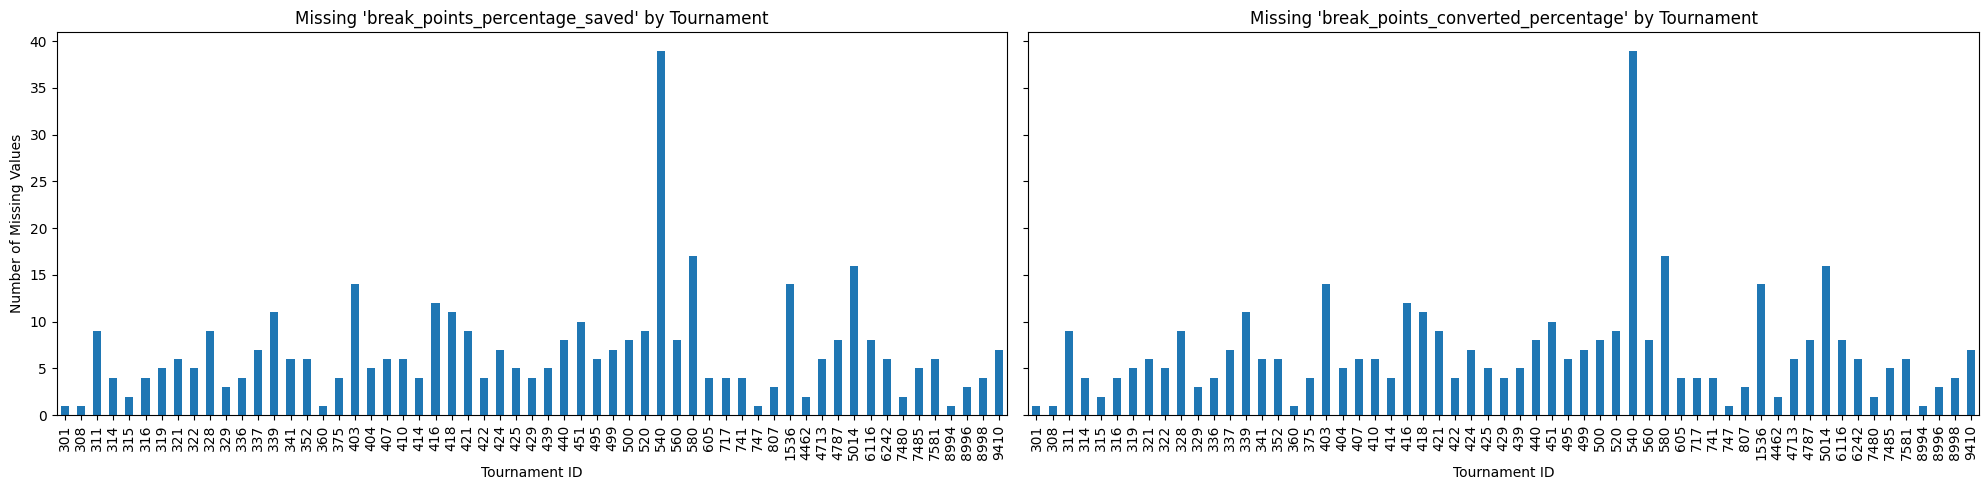

In [171]:
# Get missing value counts by tournament
missing_saved = df_matches.loc[df_matches["break_points_percentage_saved"].isna(), "tournament_id"].value_counts().sort_index()
missing_converted = df_matches.loc[df_matches["break_points_converted_percentage"].isna(), "tournament_id"].value_counts().sort_index()

# Create side-by-side bar plots
fig, axes = plt.subplots(1, 2, figsize=(20, 5), sharey=True)

missing_saved.plot(kind='bar', ax=axes[0], title="Missing 'break_points_percentage_saved' by Tournament")
axes[0].set_xlabel("Tournament ID")
axes[0].set_ylabel("Number of Missing Values")

missing_converted.plot(kind='bar', ax=axes[1], title="Missing 'break_points_converted_percentage' by Tournament")
axes[1].set_xlabel("Tournament ID")

plt.tight_layout()
plt.show()


#### We Will imput 0 -Reasoning for imputing 0 in break point stats

---
#### Explanation for identical distributions of missing break point stats

Upon inspecting the missing values for `break_points_percentage_saved` and `break_points_converted_percentage`, we observed that the **distributions across tournaments are exactly the same**.  

This is due to the way the dataset was structured: each match has been **duplicated** so that the player and opponent are swapped in separate rows. In other words, every match appears twice — once with Player A vs Player B, and once with Player B vs Player A.  

Because of this duplication, any match where **no break point opportunities occurred** (i.e., 0/0) will appear as missing values in **both rows**. As a result, the missing value pattern is **identical for both statistics** across the dataset, even though each missing value corresponds to a legitimate 0/0 situation rather than a true NaN.  

This justifies our approach to **impute 0 for these columns**, reflecting that no break points were available to be saved or converted in these matches.

---


After inspecting the distribution of missing values in the break point statistics, we observed the following:

1. 'break_points_percentage_saved' and 'break_points_converted_percentage' are missing across a wide range of tournaments (59 tournaments), unlike other stats such as 'first_serve_percentage' which have missing values concentrated in only a few tournaments.

2. This pattern suggests that the missing values are not due to missing data collection, but rather because the player had **zero break point opportunities** in those matches (i.e., denominator was effectively 0 or 0/0). I fixed the cleaning script now to return 0 instead of NaN if 0/0 and NaN if NaN.

3. Matches where the player retired early could also cause missing values, but these are rare and constitute only a small fraction of the missing cases.

Based on this reasoning, it is appropriate to **impute 0** for these columns, since a player with zero opportunities could not have saved or converted any break points. Imputing 0 preserves the semantic meaning of the statistic and ensures consistency for downstream analysis or modeling.






In [176]:
df_matches['break_points_percentage_saved'] = df_matches['break_points_percentage_saved'].fillna(0)
df_matches['break_points_converted_percentage'] = df_matches['break_points_converted_percentage'].fillna(0)
df_matches['opponent_break_points_percentage_saved'] = df_matches['break_points_percentage_saved'].fillna(0)
df_matches['opponent_break_points_converted_percentage'] = df_matches['break_points_converted_percentage'].fillna(0)

### 3.0. ```percent_net_points_won```

In [ ]:
df_matches.loc[df_matches["percent_net_points_won"].isna()]["tournament_id"].value_counts()

tournament_id
580    456
520    448
540    394
Name: count, dtype: Int64

Drop net_points_won.

It is hard to impute and I dont think it's too predictive

In [606]:
df_matches.drop(columns=["percent_net_points_won", "opponent_net_points_played", "net_points_played", "opponent_percent_net_points_won"], inplace=True)

## Save Up To This Point

In [607]:
df_matches.to_parquet("/Users/samueleferrucci/Documents/Coding/Projects/Tennis ML/data/clean/dashboard.parquet")
df_matches.to_parquet("s3://matchedge-pipeline/data/clean/dashboard.parquet")

In [608]:
df_matches = pd.read_parquet("s3://matchedge-pipeline/data/clean/dashboard.parquet")

### 4.0. Impute Duration 

Let's summarise some missing values

In [610]:
not_ret = df_matches.loc[df_matches["result"] ==  "Completed"]
for col in df_matches.columns:
    missing = not_ret[col].isna().sum()
    percent = round(missing/not_ret.shape[0]*100,1)
    if percent > 0:
        print(f"{col} has {percent}% missing values")

duration has 15.8% missing values
set3 has 53.5% missing values
set4 has 91.3% missing values
set5 has 96.6% missing values
opponent_set3 has 53.5% missing values
opponent_set4 has 91.3% missing values
opponent_set5 has 96.6% missing values
first_serve_percentage has 26.9% missing values
winners has 28.8% missing values
unforced_errors has 28.8% missing values
opponent_first_serve_percentage has 26.9% missing values
opponent_winners has 28.8% missing values
opponent_unforced_errors has 28.8% missing values


For non GS matches

In [611]:
not_GS = df_matches.loc[
    (df_matches["tournament_id"]!=540) &\
    (df_matches["tournament_id"]!=520) &\
    (df_matches["tournament_id"]!=580) &\
    (df_matches["tournament_id"]!=560) &\
    (df_matches["tournament_id"]!=7697)
    ]
for col in df_matches.columns:
    missing = not_GS[col].isna().sum()
    percent = round(missing/not_GS.shape[0]*100,1)
    if percent > 0:
        print(f"{col} has {percent}% missing values")

set2 has 0.8% missing values
set3 has 63.5% missing values
set4 has 99.6% missing values
set5 has 99.9% missing values
opponent_set2 has 0.8% missing values
opponent_set3 has 63.5% missing values
opponent_set4 has 99.6% missing values
opponent_set5 has 99.9% missing values
winners has 2.6% missing values
unforced_errors has 2.6% missing values
opponent_winners has 2.6% missing values
opponent_unforced_errors has 2.6% missing values


No missing duration, first_serve_percentage, opponent_first_serve_percentage. And reduced winners, unforced_errors and percent_net_points_won.

### Try get duration for GS From API - Only 2024

**BUT** my 2024 GS's have duration. So no help

Create column no of sets

In [612]:
df_matches["sets_played"] = df_matches["sets_won"] + df_matches["sets_lost"]

In [613]:
# ensure duration is numeric minutes
df_matches["duration"] = pd.to_timedelta(df_matches["duration"]).dt.total_seconds() / 60  

Calculate median duration for how many sets played

**For US Open**

In [614]:
# Step 1: median durations by sets played in US Open (560)
median_duration_GS_hard = df_matches.loc[df_matches["tournament_id"] == 560] \
    .assign(sets_played=lambda x: x["sets_won"] + x["sets_lost"]) \
    .groupby("sets_played")["duration"].median()

**For Wimby**

In [615]:
median_duration_wimby = df_matches.loc[(df_matches["tournament_id"] == 540) & (df_matches["year"]==2024)] \
    .assign(sets_played=lambda x: x[["sets_won", "sets_lost"]].sum(axis=1)) \
    .groupby("sets_played")["duration"].median()


**For Clay Courts**

In [616]:
median_duration_clay = (
    df_matches.loc[df_matches["surface"] == "clay"]
    .assign(sets_played=lambda x: x[["sets_won", "sets_lost"]].sum(axis=1))
    .groupby("sets_played")["duration"]
    .median()
)
median_per_set = median_duration_clay / median_duration_clay.index  # get median duration per set
median_duration_clay.loc[4] = median_per_set.median() * 4
median_duration_clay.loc[5] = median_per_set.median() * 5


median_duration_clay

sets_played
0     17.016667
1     65.050000
2     89.300000
3    142.466667
4    225.077778
5    281.347222
Name: duration, dtype: float64

Define imputing function

In [617]:
def impute_tournament_duration(df, tournament_id, year, median_durations):
    """
    Impute missing duration values for a specific tournament and year
    based on precomputed median durations per sets played.

    Parameters:
        df (pd.DataFrame): The matches DataFrame
        tournament_id: The tournament identifier
        year: The tournament year
        median_durations (pd.Series or dict): median durations indexed by sets_played

    Returns:
        pd.DataFrame: DataFrame with missing durations imputed
    """
    df = df.copy()
    mask = (df["tournament_id"] == tournament_id) &\
           (df["year"] == year) &\
           (df["duration"].isna() | df["duration"].isnull() | df["duration"].eq("Missing value"))
   
    df.loc[mask, "imputed_duration"] = 1 
    df.loc[mask, "duration"] = df.loc[mask, "sets_played"].map(median_durations)
    
    return df


create ```imputed_duration``` where 0 mean scraped duration and 1, imouted duration

In [618]:
df_matches["imputed_duration"] = np.where(df_matches["duration"].notna(), 0, np.nan)

Impute durations

In [619]:
df_match_imputed = impute_tournament_duration(df_matches, 580, 2025, median_duration_GS_hard)
df_match_imputed = impute_tournament_duration(df_match_imputed, 520, 2025, median_duration_clay)
df_match_imputed = impute_tournament_duration(df_match_imputed, 540, 2025, median_duration_wimby)

Done!!


Now check missing values for duration again

In [620]:
not_ret = df_match_imputed.loc[df_matches["result"] ==  "Completed"]

missing = not_ret["duration"].isna().sum()
percent = round(missing/not_ret.shape[0]*100,1)

print(f"duration has {percent}% missing values")

df_match_imputed[df_match_imputed["duration"].isna()]

duration has 0.0% missing values


,match_date,player,opponent,duration,match_round,winner,result,tournament_id,id,opponent_id,...,opponent_percent_total_points_won,opponent_break_point_opportunities,break_point_opportunities,target,straight_sets_win,sets_won,sets_lost,straight_sets_loss,sets_played,imputed_duration


---

In [ ]:
# df_match_imputed.drop(columns=["unforced_errors", "winners", "opponent_winners", "opponent_unforced_errors"], inplace=True)

In [ ]:
# df_match_imputed = df_match_imputed.loc[df_match_imputed["opponent_2nd_serve_return_percentage_won"].notna()]
# df_match_imputed = df_match_imputed.loc[df_match_imputed["2nd_serve_return_percentage_won"].notna()]

In [621]:
# df_match_imputed.loc[df_match_imputed["first_serve_percentage"].isna(), "level"].value_counts()

---

### 5.0. Winners + Unforced Errors - Statistical Modelling

I want to See if Winners and unforced errors are statistically significant in a player winning

First use a logistic regression

In [622]:
import statsmodels.api as sm

In [623]:
X = sm.add_constant(df_matches.loc[df_matches["winners"].notna(), "winners"])
y = df_matches.loc[df_matches["winners"].notna(), "target"]

In [624]:
model = sm.Logit(y,X).fit()
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.666077
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:                 target   No. Observations:                 5834
Model:                          Logit   Df Residuals:                     5832
Method:                           MLE   Df Model:                            1
Date:                Tue, 19 Aug 2025   Pseudo R-squ.:                 0.03905
Time:                        09:22:10   Log-Likelihood:                -3885.9
converged:                       True   LL-Null:                       -4043.8
Covariance Type:            nonrobust   LLR p-value:                 1.160e-70
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.1141      0.070    -15.855      0.000      -1.252      -0.976
winners        0.0505      0.

This shows $\log{(\text{Odds}(Y_{target}=1))}= -1.1141 + 0.0505  x_{winners}$

* *Pseudo R-squared*: Small. meaning it fits a little bit better - $4\%$ better - than the null model (intercept: $-1.1141$ only)

* *Log-Likelyhood*: This is the sum of all the $log$ predicted probabilities of target $Y$ given $x_{winners}$ : $\log{(P(y_i|x_{i}{winners}))}$

* *LL-Null*: This is the same as Log-Likelyhood but assuming the null-hypothesis $H_0$, that is: $\log{(\text{Odds}(Y_{target}=1))}= -1.1141$

* *Predictive Improvement*: Taking $2\times(LL-LL_{Null})$ gives the improvement the model adds. Here is it $\approx 316$

* *LLR p-value*: Small is good. Means there is a small probability to obtain these results assuming $H_0$ 

* *Coeff*: $0.0505$. Using equations for Log Regression we can see what this means for odds $\rightarrow$ $(\text{Odds}(Y_{target}=1))= \exp{(-1.1141 + 0.0505  x_{winners})}$. For one winner the odds increase by $\exp{(0.0505)} \approx 1.05 \rightarrow 5\%$

* *$95\%$ Confidence Interval*: The $95%$ confidence interval for the coefficient of winners ranges from 0.045 to 0.056. Under the assumptions of the model, this interval was computed in a way that, over many hypothetical repetitions of the study, 95% of such intervals would contain the true coefficient.

Is the assumtion on logit-linear relationship valid?

In [625]:
df_winners = df_matches.loc[df_matches["unforced_errors"].notna(), ["winners", "unforced_errors", "target"]]
bins_equal_width = pd.cut(df_winners["winners"], bins=3)

df_winners["winners_bin"] = bins_equal_width

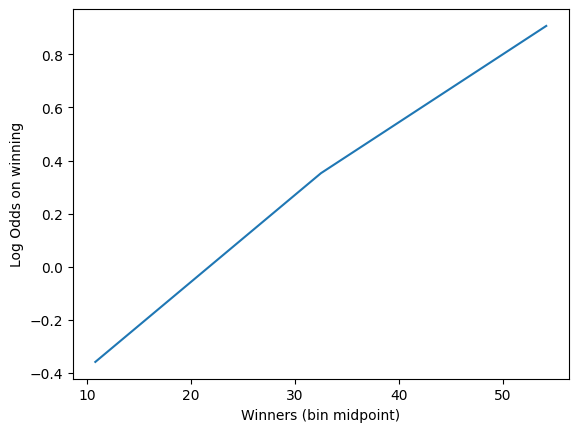

In [626]:
p_hat = df_winners.groupby("winners_bin", observed=False)["target"].sum() / df_winners.groupby("winners_bin", observed=False)["target"].count()
bin_midpoints = [interval.mid for interval in p_hat.index]
odds = p_hat/(1-p_hat)
log_odds = np.log(odds)

sns.lineplot(x=bin_midpoints, y=log_odds.values)
plt.xlabel("Winners (bin midpoint)")
plt.ylabel("Log Odds on winning")
plt.show()


There is a linear relationship between log odds and winners ✅


Now check unforced errors

In [627]:
X = sm.add_constant(df_matches.loc[df_matches["unforced_errors"].notna(), "unforced_errors"])
y = df_matches.loc[df_matches["unforced_errors"].notna(), "target"]
model = sm.Logit(y,X).fit()
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.675807
         Iterations 4
                           Logit Regression Results                           
Dep. Variable:                 target   No. Observations:                 5834
Model:                          Logit   Df Residuals:                     5832
Method:                           MLE   Df Model:                            1
Date:                Tue, 19 Aug 2025   Pseudo R-squ.:                 0.02502
Time:                        11:20:47   Log-Likelihood:                -3942.7
converged:                       True   LL-Null:                       -4043.8
Covariance Type:            nonrobust   LLR p-value:                 6.512e-46
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.7996      0.063     12.632      0.000       0.676       0.924
unforced_error

Check again if made a good assumption

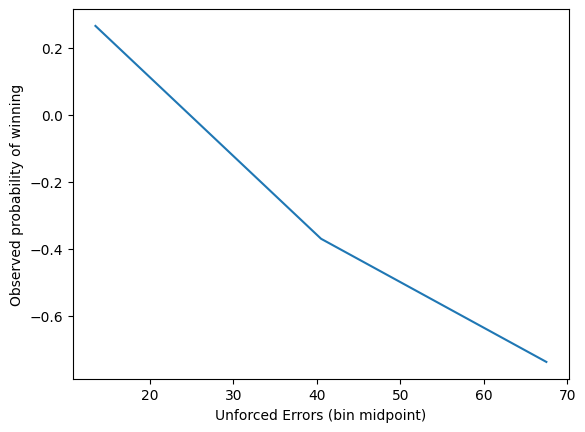

In [628]:
df_winners = df_matches.loc[df_matches["unforced_errors"].notna(), ["winners", "unforced_errors", "target"]]
bins_equal_width = pd.cut(df_winners["unforced_errors"], bins=3)

df_winners["errors_bin"] = bins_equal_width

p_hat = df_winners.groupby("errors_bin", observed=False)["target"].sum() / df_winners.groupby("errors_bin", observed=False)["target"].count()
bin_midpoints = [interval.mid for interval in p_hat.index]
odds = p_hat/(1-p_hat)
log_odds = np.log(odds)

sns.lineplot(x=bin_midpoints, y=log_odds.values)
plt.xlabel("Unforced Errors (bin midpoint)")
plt.ylabel("Observed probability of winning")
plt.show()

#### As an aside we can check both together

In [629]:
X = sm.add_constant(df_matches.loc[df_matches["unforced_errors"].notna(), ["winners", "unforced_errors"]])
y = df_matches.loc[df_matches["unforced_errors"].notna(), "target"]
model = sm.Logit(y,X).fit()
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.607268
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:                 target   No. Observations:                 5834
Model:                          Logit   Df Residuals:                     5831
Method:                           MLE   Df Model:                            2
Date:                Tue, 19 Aug 2025   Pseudo R-squ.:                  0.1239
Time:                        11:22:15   Log-Likelihood:                -3542.8
converged:                       True   LL-Null:                       -4043.8
Covariance Type:            nonrobust   LLR p-value:                2.578e-218
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -0.3479      0.079     -4.430      0.000      -0.502      -0.194
winners       

We see the p-value decreased and the *Pseudo R-squ* and *Predicted Imporvement* increased.

---
Now use Chi-Squared Test - Resampling Approach. Doesn't tell you as much as the Statsmodel logit

* *Statsmodels* logit fit → How does $X$ affect $Y$?
* *$Chi²$* goodness-of-fit → Does my model predict the outcomes well overall? **This is for predicted values. Not what I did - I used the average, expected values.** Using the average is essentially just repeating the LL-null baseline — it won’t tell you whether your predictors improve the fit.

First bin winners


In [589]:
df_winners = df_matches.loc[df_matches["unforced_errors"].notna(), ["winners", "unforced_errors", "target"]]

In [590]:
bins_equal_width = pd.qcut(df_winners["winners"], q=3)

Lets see the table of how these bins fall into win and lost

In [591]:
df_winners["winner_bin"] = bins_equal_width
counts = df_winners.groupby(["winner_bin", "target"], observed=False).size().unstack(fill_value=0).reindex(columns=[1,0])
counts

target,1,0
winner_bin,,
"(-0.001, 17.0]",682,1343
"(17.0, 25.0]",1063,804
"(25.0, 65.0]",1172,770


In [537]:
import random

In [551]:
box = [1] * df_winners["target"].sum()
box.extend([0] * (len(df_winners["target"]) - df_winners["target"].sum()))
random.shuffle(box)

def chi2(observed, expected):
    pearsons_resid = []
    for row, expect in zip(observed, expected):
        pearsons_resid.append([(observe - expect) ** 2 / expect
                               for observe in row])
    # return sum of squares
    return np.sum(pearsons_resid)
    
expected_wins = df_winners["target"].sum()/3
expected_loses = len(df_winners["target"])/3 - expected_wins
expected = [expected_wins, expected_loses]
chi2observed = chi2(counts.values, expected)

def perm_func(box):
    sample_wins = [sum(random.sample(box, len(df_winners["target"])//3)),
                   sum(random.sample(box, len(df_winners["target"])//3)),
                   sum(random.sample(box, len(df_winners["target"])//3))]
    sample_loses = [len(df_winners["target"])/3 - n for n in sample_wins]
    return chi2([sample_wins, sample_loses], expected)

perm_chi2 = [perm_func(box) for _ in range(2000)]
resampled_p_value = sum(perm_chi2 > chi2observed) / len(perm_chi2)
print(f"Observed chi2: {chi2observed:.4f}")
print(f"Resampled p-value: {resampled_p_value:.4f}")

Observed chi2: 265.5918
Resampled p-value: 0.0000


#### Winners and Unforced Errors Have Predictive Power $\rightarrow$ Impute Averages

In [633]:
df_match_imputed.loc[df_match_imputed["winners"].isna()].sort_values("match_date", ascending=True)

,match_date,player,opponent,duration,match_round,winner,result,tournament_id,id,opponent_id,...,opponent_percent_total_points_won,opponent_break_point_opportunities,break_point_opportunities,target,straight_sets_win,sets_won,sets_lost,straight_sets_loss,sets_played,imputed_duration
6122,2024-07-14,N. Djokovic,C. Alcaraz,147.0,Final,C. Alcaraz,Completed,540,d643,a0e2,...,0.56,14.0,3.0,0,0,0,3,1,3,0.0
6203,2024-07-14,M. Arnaldi,F. Tiafoe,189.0,Round of 128,F. Tiafoe,Completed,540,a0fc,td51,...,0.53,11.0,8.0,0,0,2,3,0,5,0.0
6202,2024-07-14,E. Ymer,J. Draper,197.0,Round of 128,J. Draper,Completed,540,y218,d0co,...,0.54,17.0,11.0,0,0,2,3,0,5,0.0
6201,2024-07-14,D. Elahi Galan,T. Griekspoor,121.0,Round of 128,T. Griekspoor,Completed,540,ge33,gj37,...,0.53,9.0,0.0,0,0,0,3,1,3,0.0
6200,2024-07-14,F. Cerundolo,R. Safiullin,206.0,Round of 128,R. Safiullin,Completed,540,c0au,sx50,...,0.53,19.0,10.0,0,0,2,3,0,5,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3653,2025-07-11,T. Fritz,C. Alcaraz,166.5,Semi-Finals,C. Alcaraz,Completed,540,fb98,a0e2,...,0.52,7.0,2.0,0,0,1,3,0,4,1.0
3652,2025-07-11,J. Sinner,N. Djokovic,128.0,Semi-Finals,J. Sinner,Completed,540,s0ag,d643,...,0.43,2.0,10.0,1,1,3,0,0,3,1.0
7751,2025-07-11,N. Djokovic,J. Sinner,128.0,Semi-Finals,J. Sinner,Completed,540,d643,s0ag,...,0.57,10.0,2.0,0,0,0,3,1,3,1.0
7750,2025-07-13,C. Alcaraz,J. Sinner,166.5,Final,J. Sinner,Completed,540,a0e2,s0ag,...,0.52,9.0,6.0,0,0,1,3,0,4,1.0


In [654]:
# Assume df has columns: 'player', 'match_date', 'winners', 'unforced_errors'
df = df_match_imputed.sort_values(['player', 'match_date'])

# Compute rolling mean over the last N matches
df['winners_roll'] = df.groupby('player')['winners'].transform(lambda x: x.shift().rolling(20, min_periods=1).median())
df['unforced_errors_roll'] = df.groupby('player')['unforced_errors'].transform(lambda x: x.shift().rolling(20, min_periods=1).median())
df['opponent_winners_roll'] = df.groupby('player')['opponent_winners'].transform(lambda x: x.shift().rolling(20, min_periods=1).median())
df['opponent_unforced_errors_roll'] = df.groupby('player')['opponent_unforced_errors'].transform(lambda x: x.shift().rolling(20, min_periods=1).median())


In [655]:
df.loc[df["winners"].isna(), ["match_date", "player", "winners", "unforced_errors", "opponent_winners", "opponent_unforced_errors", "winners_roll", "unforced_errors_roll", "opponent_winners_roll", "opponent_unforced_errors_roll"]]

,match_date,player,winners,unforced_errors,opponent_winners,opponent_unforced_errors,winners_roll,unforced_errors_roll,opponent_winners_roll,opponent_unforced_errors_roll
6335,2024-07-14,A. Andreev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
382,2025-01-06,A. Andreev,NaN,NaN,NaN,NaN,8.0,43.0,15.0,32.0
351,2025-01-07,A. Blockx,NaN,NaN,NaN,NaN,16.0,25.0,23.0,25.0
7881,2025-06-26,A. Blockx,NaN,NaN,NaN,NaN,22.0,26.0,23.0,34.0
2149,2024-07-14,A. Bolt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
1819,2025-05-21,Z. Svajda,NaN,NaN,NaN,NaN,19.0,18.0,22.0,24.0
7889,2025-06-25,Z. Svajda,NaN,NaN,NaN,NaN,17.5,19.0,22.0,24.0
6168,2024-07-14,Z. Zhang,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6898,2024-09-08,Z. Zhang,NaN,NaN,NaN,NaN,18.0,7.0,23.0,11.0


In [668]:
df.loc[(df["winners_roll"].isna()) & (df["winners"].isna()),
       ["match_date", "player", "winners", "unforced_errors", "opponent_winners", "opponent_unforced_errors", "winners_roll", "unforced_errors_roll", "opponent_winners_roll", "opponent_unforced_errors_roll"]]

,match_date,player,winners,unforced_errors,opponent_winners,opponent_unforced_errors,winners_roll,unforced_errors_roll,opponent_winners_roll,opponent_unforced_errors_roll
6335,2024-07-14,A. Andreev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2149,2024-07-14,A. Bolt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2178,2024-07-14,A. Bolt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2219,2024-07-14,A. Bolt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6183,2024-07-14,A. Bolt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
6209,2024-07-14,Z. Bergs,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6301,2024-07-14,Z. Piros,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2208,2024-07-14,Z. Svajda,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6268,2024-07-14,Z. Svajda,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [672]:
df = df.loc[~((df["winners_roll"].isna()) & (df["winners"].isna()))].copy()

In [677]:
df = df.loc[~((df["opponent_winners_roll"].isna()) & (df["opponent_winners"].isna()))].copy()

Now impute winners and unfocred with rolling **IF** they are missing 

Create imputed ```bool``` column

In [685]:
df["imputed_winners"] = 0
df["imputed_unforced_errors"] = 0
df["imputed_opponent_winners"] = 0
df["imputed_opponent_unforced_errors"] = 0

Fill those columns then Impute

In [688]:
mask = df['winners'].isna()                                 # record which rows are missing
df.loc[mask, 'imputed_winners'] = 1                         # flag those rows as imputed
df['winners'] = df['winners'].fillna(df['winners_roll'])    # fill NaNs

mask = df['unforced_errors'].isna()                                 
df.loc[mask, 'imputed_unforced_errors'] = 1 
df['unforced_errors'] = df['unforced_errors'].fillna(df['unforced_errors_roll'])

mask = df['opponent_winners'].isna()                                 
df.loc[mask, 'imputed_opponent_winners'] = 1 
df['opponent_winners'] = df['opponent_winners'].fillna(df['opponent_winners_roll'])

mask = df['opponent_unforced_errors'].isna()                                 
df.loc[mask, 'imputed_opponent_unforced_errors'] = 1 
df['opponent_unforced_errors'] = df['opponent_unforced_errors'].fillna(df['opponent_unforced_errors_roll'])

In [703]:
df.drop(columns=["unforced_errors_roll", "opponent_winners_roll", "opponent_unforced_errors_roll", 
        "winners_roll", "winners_roll"], inplace=True)

---
### 6.0. first_serve_percentage

In [729]:
df = df.loc[~df["2nd_serve_percentage_won"].isna()].copy()

In [748]:
df = df.loc[~df["2nd_serve_return_percentage_won"].isna()].copy()

In [739]:
X = sm.add_constant(df.loc[df["serve_rating"].notna(), ["serve_rating","return_rating"]])
y = df.loc[df["serve_rating"].notna(), "target"]
model = sm.Logit(y, X).fit()
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.423472
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                 target   No. Observations:                 7507
Model:                          Logit   Df Residuals:                     7504
Method:                           MLE   Df Model:                            2
Date:                Tue, 19 Aug 2025   Pseudo R-squ.:                  0.3891
Time:                        14:28:48   Log-Likelihood:                -3179.0
converged:                       True   LL-Null:                       -5203.4
Covariance Type:            nonrobust   LLR p-value:                     0.000
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const           -11.0379      0.268    -41.218      0.000     -11.563     -10.513
serve_rating      0.

In [749]:
X = sm.add_constant(df.loc[df["first_serve_percentage"].notna(), ["1st_serve_percentage_won","2nd_serve_percentage_won", "first_serve_percentage", "1st_serve_return_percentage_won", "2nd_serve_return_percentage_won"]])
y = df.loc[df["first_serve_percentage"].notna(), "target"]
model = sm.Logit(y, X).fit()
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.230304
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:                 target   No. Observations:                 5961
Model:                          Logit   Df Residuals:                     5955
Method:                           MLE   Df Model:                            5
Date:                Tue, 19 Aug 2025   Pseudo R-squ.:                  0.6677
Time:                        14:32:15   Log-Likelihood:                -1372.8
converged:                       True   LL-Null:                       -4131.8
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const                             -42.7274      1.289    -33.159  

In [ ]:
df["return_points_percent_won"]

,match_date,player,opponent,duration,match_round,winner,result,tournament_id,id,opponent_id,...,sets_won,sets_lost,straight_sets_loss,sets_played,imputed_duration,imputed_winners,imputed_unforced_errors,imputed_opponent_winners,imputed_opponent_unforced_errors,fsp_sq


---
---

In [638]:
df1 = df_match_imputed.groupby('player')['unforced_errors']
df1

In [456]:
df_matches.groupby("sets_played")["duration"].mean()

sets_played
0     61.624000
1     61.922121
2     88.626024
3    139.954455
4    174.088608
5    222.035088
Name: duration, dtype: float64

In [487]:
match_counts = df_matches["player"].value_counts().reset_index()
match_counts.columns = ["player", "match_count"]

avg_stats = df_matches.groupby(by="player")["first_serve_percentage"].mean().reset_index()

avg_stats = avg_stats.merge(match_counts, on="player")

filtered_data = avg_stats[avg_stats["match_count"] >= 25]

avg_first_serve = filtered_data.sort_values(by="first_serve_percentage", ascending=False).head(10)

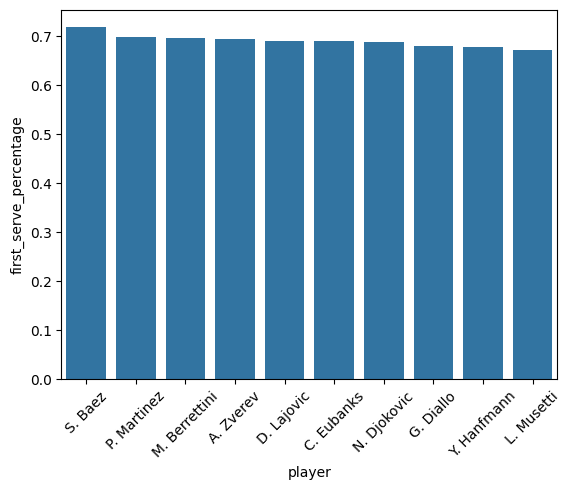

In [488]:
sns.barplot(data=avg_first_serve, y="first_serve_percentage", x="player")
plt.xticks(rotation=45)
plt.tight_layout
plt.show()

<Axes: xlabel='sets_played', ylabel='duration'>

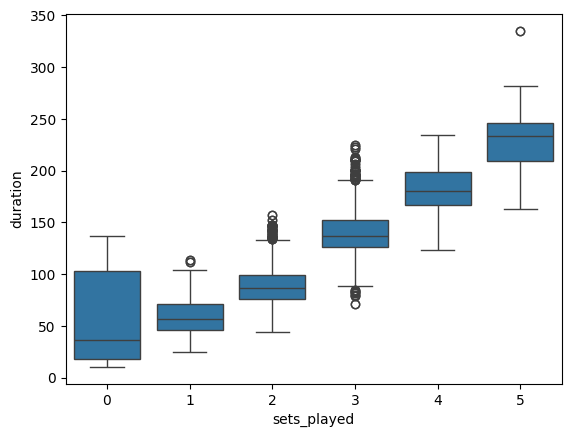

In [ ]:
sns.boxplot(data=df_match_imputed, y="first_serve_percentage", x="sets_played")

<Axes: xlabel='surface', ylabel='aces'>

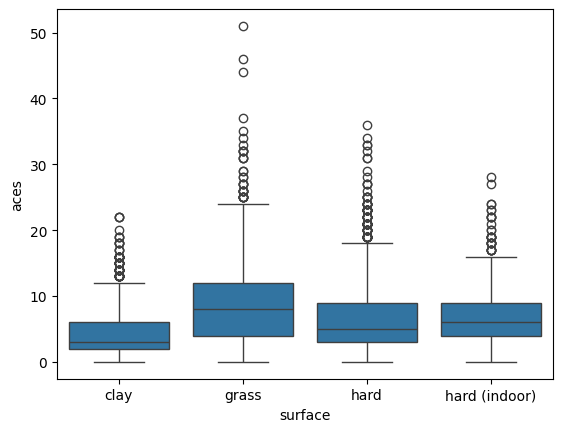

In [205]:
sns.boxplot(data=df_matches, y="aces", x="surface")

<Axes: xlabel='surface', ylabel='double_faults'>

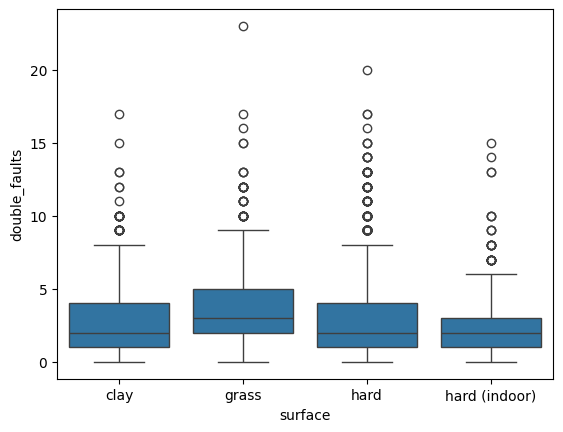

In [206]:
sns.boxplot(data=df_matches, y="double_faults", x="surface")

<Axes: xlabel='surface', ylabel='duration'>

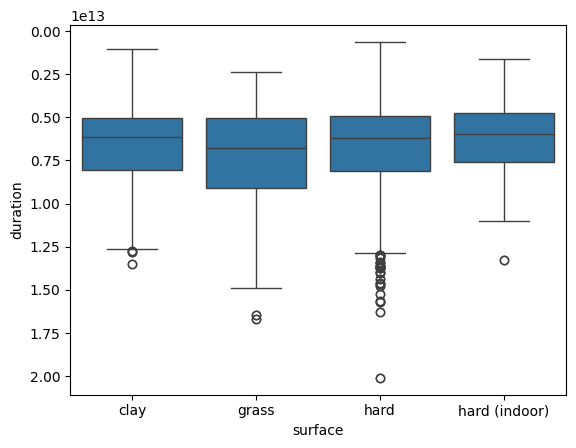

In [207]:
sns.boxplot(data=df_matches, y="duration", x="surface")

In [37]:
rankings_df = pd.read_csv("s3://matchedge-pipeline/data/clean/top_500_players.csv")

In [38]:
rankings_df = rankings_df.iloc[0:10,:]

In [39]:
rankings_df['rank'] = range(1, len(rankings_df) + 1)

In [ ]:
df_matches = pd.merge(df_matches, rankings_df[["id", "rank"]], on="id", how="left").rename(columns={"rank": "live_ranking"})

In [ ]:
df_matches

,match_date,player,opponent,duration,match_round,player_scores,opponent_scores,winner,result,tournament_id,...,return_games_played,net_points_won,winners,unforced_errors,service_points_won,return_points_won,total_points_won,break_point_opportunities,net_points_played,live_ranking
0,2025-01-05,R. Opelka,J. Lehecka,0 days 00:13:09,Final,1,4,J. Lehecka,RET,339,...,3.0,NaN,2.0,6.0,0.44,0.20,0.29,0.0,0.0,NaN
1,2025-01-04,J. Lehecka,G. Dimitrov,0 days 01:23:33,Semi-Finals,6 4,4 4,J. Lehecka,RET,339,...,9.0,0.80,17.0,22.0,0.75,0.27,0.51,2.0,5.0,NaN
2,2025-01-04,R. Opelka,G. Mpetshi Perricard,0 days 01:26:13,Semi-Finals,6 7,3 6(4),R. Opelka,Completed,339,...,10.0,0.71,27.0,16.0,0.80,0.32,0.55,2.0,17.0,NaN
3,2025-01-03,N. Djokovic,R. Opelka,0 days 01:40:11,Quarter-Finals,6(6) 3,7 6,R. Opelka,Completed,339,...,11.0,0.50,15.0,15.0,0.68,0.20,0.46,1.0,4.0,6.0
4,2025-01-03,J. Thompson,G. Dimitrov,0 days 00:43:03,Quarter-Finals,1 1,6 2,G. Dimitrov,RET,339,...,5.0,0.50,5.0,14.0,0.50,0.23,0.35,0.0,8.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8193,2025-07-19 00:00:00,N. Oberleitner,T. Monteiro,0 days 02:41:05,1st Round Qualifying,4 6 6(4),6 4 7,T. Monteiro,Completed,319,...,16.0,0.67,39.0,49.0,0.63,0.31,0.48,9.0,27.0,NaN
8194,2025-07-19 00:00:00,J. Kym,R. Albot,0 days 02:08:57,1st Round Qualifying,6 6(3) 3,2 7 6,R. Albot,Completed,319,...,15.0,0.17,27.0,45.0,0.65,0.42,0.52,10.0,6.0,NaN
8195,2025-07-19 00:00:00,H. Rocha,F. Bagnis,0 days 01:24:25,1st Round Qualifying,4 3,6 6,F. Bagnis,Completed,319,...,10.0,1.00,16.0,28.0,0.53,0.32,0.43,3.0,2.0,NaN
8196,2025-07-19 00:00:00,J. Rodionov,S. Kopp,0 days 01:20:52,1st Round Qualifying,6 7,3 6(3),J. Rodionov,Completed,319,...,10.0,0.67,26.0,25.0,0.66,0.33,0.52,3.0,9.0,NaN


<Axes: xlabel='live_ranking', ylabel='1st_serve_return_points_won'>

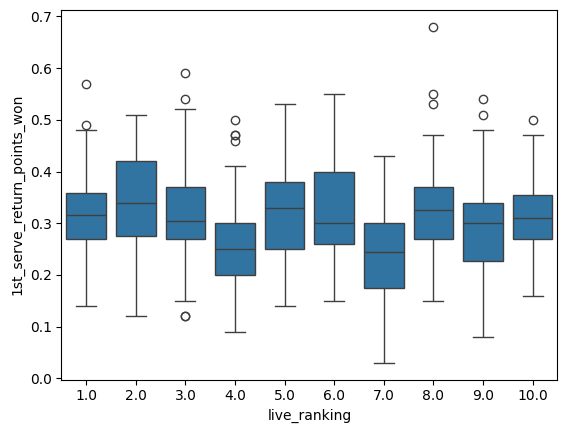

In [ ]:
sns.boxplot(data=df_matches, y="1st_serve_return_points_won", x="live_ranking")

<Axes: xlabel='live_ranking', ylabel='2nd_serve_return_points_won'>

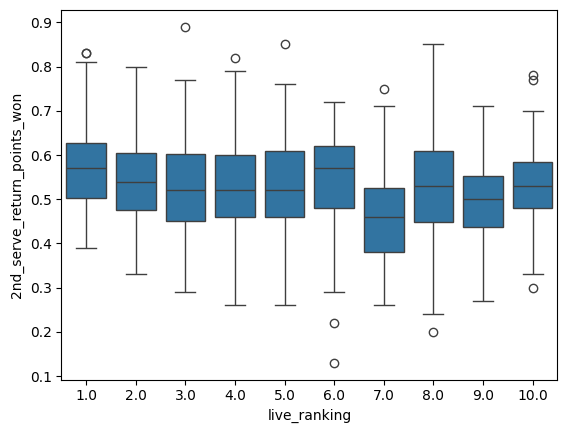

In [ ]:
sns.boxplot(data=df_matches, y="2nd_serve_return_points_won", x="live_ranking")

In [ ]:
avg_2nd_serve_return = df_matches.groupby(by=["live_ranking"])["2nd_serve_return_points_won"].mean().reset_index()

In [47]:
avg_2nd_serve_return

,live_ranking,2nd_serve_return_points_won
0,1.0,0.582581
1,2.0,0.545467
2,3.0,0.523625
3,4.0,0.534154
4,5.0,0.530656
5,6.0,0.539200
6,7.0,0.456061
7,8.0,0.526500
8,9.0,0.490667
9,10.0,0.537458


<Axes: xlabel='live_ranking', ylabel='2nd_serve_return_points_won'>

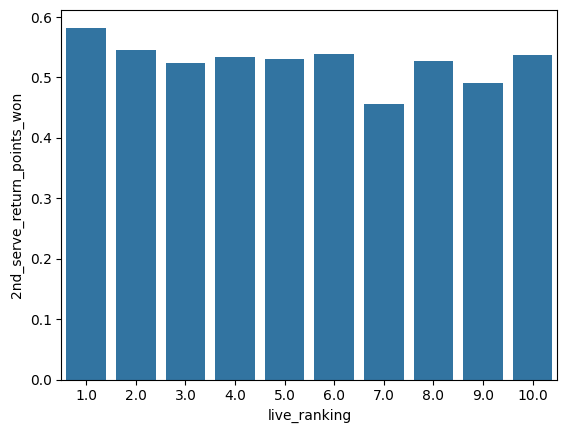

In [48]:
sns.barplot(data=avg_2nd_serve_return, y="2nd_serve_return_points_won", x="live_ranking")

In [ ]:
avg_aces_top_10 = df_matches.groupby(by=["live_ranking"])["aces"].mean().reset_index()
avg_double_faults_top_10 = df_matches.groupby(by=["live_ranking"])["double_faults"].mean().reset_index()

<Axes: xlabel='live_ranking', ylabel='double_faults'>

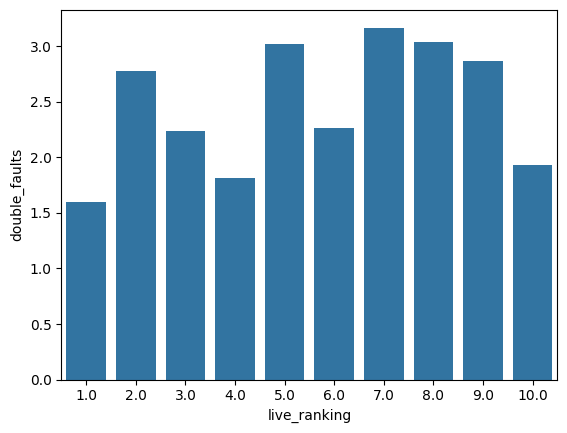

In [50]:
sns.barplot(data=avg_double_faults_top_10, y="double_faults", x="live_ranking")

<Axes: xlabel='live_ranking', ylabel='aces'>

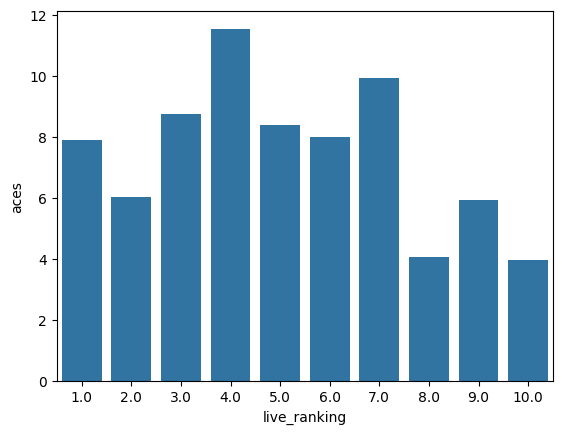

In [51]:
sns.barplot(data=avg_aces_top_10, y="aces", x="live_ranking")

In [52]:
rankings_df

,unnamed: 0,name,id,rank
0,0,J. Sinner,s0ag,1
1,1,C. Alcaraz,a0e2,2
2,2,A. Zverev,z355,3
3,3,T. Fritz,fb98,4
4,4,J. Draper,d0co,5
5,5,N. Djokovic,d643,6
6,6,B. Shelton,s0s1,7
7,7,A. de Minaur,dh58,8
8,8,H. Rune,r0dg,9
9,9,L. Musetti,m0ej,10


In [ ]:
avg_aces = df_matches.groupby(by=["player"])["aces"].mean().reset_index().sort_values(by="aces", ascending=False).iloc[:10]
avg_double = df_matches.groupby(by=["player"])["double_faults"].mean().reset_index().sort_values(by="double_faults", ascending=False).iloc[:10]

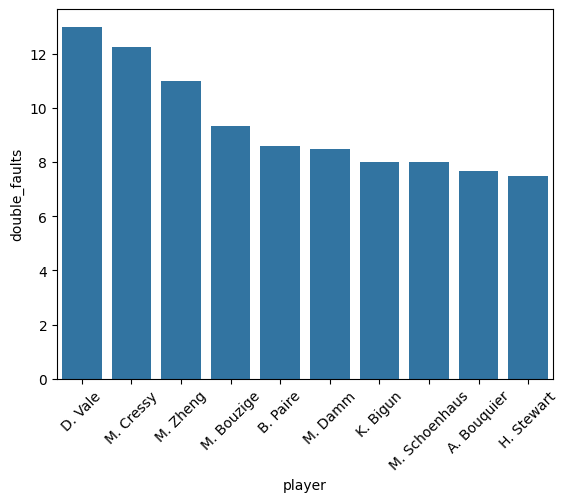

In [54]:
sns.barplot(data=avg_double, y="double_faults", x="player")
plt.xticks(rotation=45)
plt.tight_layout
plt.show()

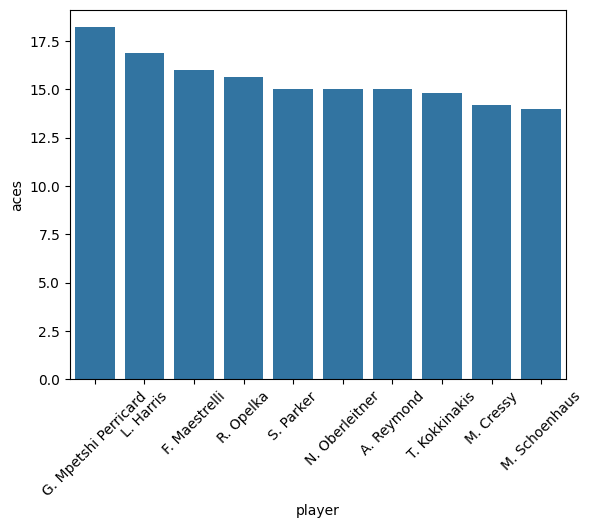

In [55]:
sns.barplot(data=avg_aces, y="aces", x="player")
plt.xticks(rotation=45)
plt.tight_layout
plt.show()

---
---
---
---
---
---
---
---

## Feature Engineering

In [92]:
def generate_rolling_features(df, stats_cols=None, N_list=[3, 5, 10]):
    """
    Generates rolling and lagged features for tennis matches using in-play stats.
    Avoids DataFrame fragmentation by concatenating results in batches.
    """

    df = df.copy()
    df['match_date'] = pd.to_datetime(df['match_date'], errors='coerce')  # keep datetime
    df = df.sort_values(['player', 'match_date'])

    if stats_cols is None:
        stats_cols = [
            'serve_rating', 'aces', 'double_faults', 'first_serve_percentage',
            '1st_serve_percentage_won', '2nd_serve_percentage_won',
            'break_points_percentage_saved', 'service_games_played', 'return_rating',
            '1st_serve_return_percentage_won', '2nd_serve_return_percentage_won',
            'break_points_converted_percentage', 'return_games_played',
            'percent_net_points_won', 'winners', 'unforced_errors',
            'service_points_percent_won', 'return_points_percent_won',
            'percent_total_points_won', 'break_point_opportunities', 'net_points_played'
        ]

    all_new_cols = []

    # Player-based rolling features
    for N in N_list:
        rolling_group = df.groupby('player', group_keys=False)[stats_cols]
        rolled_mean = rolling_group.apply(lambda x: x.shift().rolling(N, min_periods=1).mean())
        rolled_sum = rolling_group.apply(lambda x: x.shift().rolling(N, min_periods=1).sum())

        rolled_mean.columns = [f'{col}_rolling_mean_{N}' for col in stats_cols]
        rolled_sum.columns = [f'{col}_rolling_sum_{N}' for col in stats_cols]

        all_new_cols.append(rolled_mean)
        all_new_cols.append(rolled_sum)

    # Surface-specific rolling
    for N in N_list:
        surface_group = df.groupby(['player', 'surface'], group_keys=False)[stats_cols]
        surf_mean = surface_group.apply(lambda x: x.shift().rolling(N, min_periods=1).mean())
        surf_mean.columns = [f'{col}_surf_mean_{N}' for col in stats_cols]
        all_new_cols.append(surf_mean)

    # Head-to-head rolling stats
    for N in N_list:
        h2h_group = df.groupby(['player', 'opponent'], group_keys=False)

        h2h_wins = h2h_group['target'].apply(
            lambda x: x.shift().rolling(N, min_periods=1).apply(lambda s: np.sum(s == 1), raw=False)
        )
        h2h_wins.name = f'h2h_wins_{N}'
        all_new_cols.append(h2h_wins)

        h2h_sets_diff = h2h_group['sets_won'].transform(
    lambda x: (x - h2h_group['sets_lost'].get_group(x.name)).shift().rolling(N, min_periods=1).sum()
)

        h2h_sets_diff.name = f'h2h_sets_diff_{N}'
        all_new_cols.append(h2h_sets_diff)

    # Recent win rate
    for N in N_list:
        win_rate = df.groupby('player')['target'].apply(
            lambda x: x.shift().rolling(N, min_periods=1).mean()
        )
        win_rate.name = f'recent_win_rate_{N}'
        all_new_cols.append(win_rate)

    # Ranking difference & trend
            # ranking_diff = df['live_ranking'] - df['opponent'].map(
            #     df.groupby('player')['live_ranking'].last()
            # )
            # ranking_diff.name = 'ranking_diff'
            # all_new_cols.append(ranking_diff)

            # for N in N_list:
            #     rank_change = df.groupby('player')['live_ranking'].apply(
            #         lambda x: x.shift(N) - x
            #     )
            #     rank_change.name = f'ranking_change_{N}'
            #     all_new_cols.append(rank_change)

    # Merge all at once
    df = pd.concat([df] + all_new_cols, axis=1)

    return df

In [93]:
def format_stat_cols(df, tournament_order):
    """
    Formats key columns in the match statistics DataFrame by setting appropriate data types.

    Parameters:
        df (pd.DataFrame): The input DataFrame with raw statistical data.
        tournament_order (list): Ordered list of tournament levels for categorical conversion.

    Returns:
        pd.DataFrame: The DataFrame with properly typed and formatted columns.
    """
    # Convert identifiers and player/opponent info
    df['player'] = df['player'].astype('string')
    df['opponent'] = df['opponent'].astype('string')
    df['id'] = df['id'].astype('string').str.lower()
    df['opponent_id'] = df['opponent_id'].astype('string').str.lower()
    df['tournament_id'] = df['tournament_id'].astype('Int64')
    df['winner'] = df['winner'].astype('string')

    # Tournament info
    df['level'] = pd.Categorical(df['level'], categories=tournament_order, ordered=True)
    df['location'] = df['location'].astype('string')
    df['surface'] = df['surface'].astype('category')

    # Dates and duration
    df['match_date'] = pd.to_datetime(df['match_date'], errors='coerce').dt.date

    df['year'] = df['year'].astype('Int64')
    df['duration'] = pd.to_timedelta(df['duration'], errors='coerce')

    # Integer columns
    int_cols = [
        'set1', 'set2', 'set3', 'set4', 'set5',
        'opponent_set1', 'opponent_set2', 'opponent_set3', 'opponent_set4', 'opponent_set5',
        'best_of', 'target', 'straight_sets_win', 'straight_sets_loss',
        'sets_won', 'sets_lost', 'live_ranking'
    ]
    for col in int_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce').astype('Int64')

    # Float/stat columns
    stats_cols = [
        'serve_rating', 'aces', 'double_faults', 'first_serve_percentage',
        '1st_serve_percentage_won', '2nd_serve_percentage_won',
        'break_points_percentage_saved', 'service_games_played', 'return_rating',
        '1st_serve_return_percentage_won', '2nd_serve_return_percentage_won',
        'break_points_converted_percentage', 'return_games_played',
        'percent_net_points_won', 'winners', 'unforced_errors',
        'service_points_percent_won', 'return_points_percent_won',
        'percent_total_points_won', 'break_point_opportunities', 'net_points_played'
    ]
    for col in stats_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    return df


In [ ]:
tournament_order = [
    'Next Gen ATP Finals',
    'ATP 250',
    'ATP 500',
    'ATP 1000',
    'Nitto ATP Finals',
    'Grand Slam'
]
rolling_stats_df = format_stat_cols(df_matches, tournament_order=tournament_order)

In [ ]:
player_stats_atp_df = df_matches[df_matches["best_of"] != 5].copy()

In [97]:
player_stats_atp_df = player_stats_atp_df[player_stats_atp_df['duration'].notna()]

In [98]:
player_stats_atp_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6404 entries, 0 to 8197
Data columns (total 54 columns):
 #   Column                             Non-Null Count  Dtype          
---  ------                             --------------  -----          
 0   match_date                         6404 non-null   object         
 1   player                             6404 non-null   string         
 2   opponent                           6404 non-null   string         
 3   duration                           6404 non-null   timedelta64[ns]
 4   match_round                        6404 non-null   object         
 5   winner                             6404 non-null   string         
 6   result                             6404 non-null   object         
 7   tournament_id                      6404 non-null   Int64          
 8   id                                 6404 non-null   string         
 9   opponent_id                        6404 non-null   string         
 10  set1                         

In [102]:
player_stats_atp_df = player_stats_atp_df[player_stats_atp_df['result'] != 'RET']

In [103]:
player_stats_atp_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6248 entries, 2 to 8197
Data columns (total 54 columns):
 #   Column                             Non-Null Count  Dtype          
---  ------                             --------------  -----          
 0   match_date                         6248 non-null   object         
 1   player                             6248 non-null   string         
 2   opponent                           6248 non-null   string         
 3   duration                           6248 non-null   timedelta64[ns]
 4   match_round                        6248 non-null   object         
 5   winner                             6248 non-null   string         
 6   result                             6248 non-null   object         
 7   tournament_id                      6248 non-null   Int64          
 8   id                                 6248 non-null   string         
 9   opponent_id                        6248 non-null   string         
 10  set1                         

In [ ]:
player_stats_atp_df.drop(columns='live_ranking', inplace=True)

In [106]:
player_stats_atp_df.drop(columns='winner_not_in_match', inplace=True)

In [ ]:
player_stats_atp_df = format_stat_cols(df_matches, tournament_order=tournament_order)

In [115]:
player_stats_atp_df

,match_date,player,opponent,duration,match_round,winner,result,tournament_id,id,opponent_id,...,percent_total_points_won,break_point_opportunities,net_points_played,live_ranking,target,straight_sets_win,straight_sets_loss,sets_won,sets_lost,winner_not_in_match
0,2025-01-05,R. Opelka,J. Lehecka,0 days 00:13:09,Final,J. Lehecka,RET,339,o522,l0bv,...,0.29,0.0,0.0,<NA>,0,0,1,0,0,False
1,2025-01-04,J. Lehecka,G. Dimitrov,0 days 01:23:33,Semi-Finals,J. Lehecka,RET,339,l0bv,d875,...,0.51,2.0,5.0,<NA>,1,1,0,1,0,False
2,2025-01-04,R. Opelka,G. Mpetshi Perricard,0 days 01:26:13,Semi-Finals,R. Opelka,Completed,339,o522,m0gz,...,0.55,2.0,17.0,<NA>,1,1,0,2,0,False
3,2025-01-03,N. Djokovic,R. Opelka,0 days 01:40:11,Quarter-Finals,R. Opelka,Completed,339,d643,o522,...,0.46,1.0,4.0,6,0,0,1,0,2,False
4,2025-01-03,J. Thompson,G. Dimitrov,0 days 00:43:03,Quarter-Finals,G. Dimitrov,RET,339,tc61,d875,...,0.35,0.0,8.0,<NA>,0,0,1,0,1,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8193,2025-07-19,N. Oberleitner,T. Monteiro,0 days 02:41:05,1st Round Qualifying,T. Monteiro,Completed,319,o0ad,mj08,...,0.48,9.0,27.0,<NA>,0,0,0,1,2,False
8194,2025-07-19,J. Kym,R. Albot,0 days 02:08:57,1st Round Qualifying,R. Albot,Completed,319,k0ep,a829,...,0.52,10.0,6.0,<NA>,0,0,0,1,2,False
8195,2025-07-19,H. Rocha,F. Bagnis,0 days 01:24:25,1st Round Qualifying,F. Bagnis,Completed,319,r0go,bf23,...,0.43,3.0,2.0,<NA>,0,0,1,0,2,False
8196,2025-07-19,J. Rodionov,S. Kopp,0 days 01:20:52,1st Round Qualifying,J. Rodionov,Completed,319,r09x,k0cj,...,0.52,3.0,9.0,<NA>,1,1,0,2,0,False


In [ ]:
player_stats_atp_df = generate_rolling_features(df_matches)

/var/folders/b3/8dnps2js0rz1xgw1gkx248p40000gn/T/ipykernel_58215/1542774931.py:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  surface_group = df.groupby(['player', 'surface'], group_keys=False)[stats_cols]
/var/folders/b3/8dnps2js0rz1xgw1gkx248p40000gn/T/ipykernel_58215/1542774931.py:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  surface_group = df.groupby(['player', 'surface'], group_keys=False)[stats_cols]
/var/folders/b3/8dnps2js0rz1xgw1gkx248p40000gn/T/ipykernel_58215/1542774931.py:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of panda

In [117]:
player_stats_atp_df

,match_date,player,opponent,duration,match_round,winner,result,tournament_id,id,opponent_id,...,net_points_played_surf_mean_10,h2h_wins_3,h2h_sets_diff_3,h2h_wins_5,h2h_sets_diff_5,h2h_wins_10,h2h_sets_diff_10,recent_win_rate_3,recent_win_rate_5,recent_win_rate_10
5190,2025-03-29,A. Andrade,P. Maloney,0 days 01:43:58,1st Round Qualifying,P. Maloney,RET,717,ag08,m0re,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6335,2024-07-14,A. Andreev,R. Molleker,0 days 01:08:00,1st Round Qualifying,R. Molleker,Completed,540,a0ab,m0ac,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7430,2024-10-20,A. Andreev,L. Djere,0 days 01:32:00,1st Round Qualifying,L. Djere,Completed,429,a0ab,db63,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
43,2024-12-28,A. Andreev,C. Tseng,0 days 02:52:37,1st Round Qualifying,A. Andreev,Completed,339,a0ab,t0ap,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4131,2024-12-29,A. Andreev,B. Bonzi,0 days 00:20:21,2nd Round Qualifying,B. Bonzi,RET,339,a0ab,bm95,...,8.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"(Z. Zhang, 509)",NaT,<NA>,<NA>,NaT,NaN,<NA>,NaN,<NA>,<NA>,<NA>,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.333333,0.2,0.2
"(Z. Zhang, 4605)",NaT,<NA>,<NA>,NaT,NaN,<NA>,NaN,<NA>,<NA>,<NA>,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.666667,0.4,0.2
"(Z. Zhang, 634)",NaT,<NA>,<NA>,NaT,NaN,<NA>,NaN,<NA>,<NA>,<NA>,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.666667,0.4,0.2
"(Z. Zhang, 4818)",NaT,<NA>,<NA>,NaT,NaN,<NA>,NaN,<NA>,<NA>,<NA>,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.333333,0.4,0.2
